# Part C: Text Classification with RNNs

This notebook ports `rnn.py` into a structured notebook and extends it with multiple RNN/LSTM architectures,
t-SNE visualization of learned embeddings, and several experimental variations.

## 1. Imports & Configuration

In [1]:
%pip install torch==2.3.0 torchtext==0.18.0
%pip install pandas numpy tqdm scikit-learn matplotlib seaborn gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 779.1/779.1 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 96.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 111.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 86.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 65.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 725.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.2/176.2 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchtext.data import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator
import pandas as pd
import numpy as np
import time
import copy
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import gensim.downloader as api

sns.set_style('whitegrid')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

/usr/local/lib/python3.12/dist-packages/torchtext/data/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
/usr/local/lib/python3.12/dist-packages/torchtext/vocab/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
/usr/local/lib/python3.12/dist-packages/torchtext/utils.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated

Using device: cuda


## 2. Hyperparameters

Toggle **`MAX_WORDS`**, **`USE_GLOVE`**, **`FREEZE_EMBEDDINGS`**, and **`USE_IMDB`** to run the variations.

In [2]:
# Static Hyperparameters (These apply to all variations)
EPOCHS = 15
LEARNING_RATE = 1e-3
BATCH_SIZE = 1024
EMBEDDING_DIM = 100
HIDDEN_DIM = 64
NUM_RUNS = 3


In [3]:
def train_model(model, loss_fn, optimizer, train_loader, epochs):
    epoch_times = []
    for epoch in range(1, epochs + 1):
        model.train()
        losses = []
        start = time.time()
        for X, Y in tqdm(train_loader, desc=f'Epoch {epoch}', leave=False):
            preds = model(X)
            loss = loss_fn(preds, Y)
            losses.append(loss.item())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        elapsed = time.time() - start
        epoch_times.append(elapsed)
        print(f'Epoch {epoch:2d} | Loss: {np.mean(losses):.4f} | Time: {elapsed:.1f}s')
    return epoch_times

In [4]:
def evaluate_model(model, loss_fn, test_loader):
    model.eval()
    with torch.no_grad():
        Y_actual, Y_preds, losses = [], [], []
        for X, Y in test_loader:
            preds = model(X)
            loss = loss_fn(preds, Y)
            losses.append(loss.item())
            Y_actual.append(Y)
            Y_preds.append(preds.argmax(dim=-1))
        Y_actual = torch.cat(Y_actual)
        Y_preds = torch.cat(Y_preds)
    return (torch.tensor(losses).mean().item(),
            Y_actual.detach().cpu().numpy(),
            Y_preds.detach().cpu().numpy())

In [5]:
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim,
                 rnn_type='RNN', bidirectional=False, num_layers=1,
                 pretrained_embeddings=None, freeze_embeddings=False):
        super(RNNClassifier, self).__init__()
        self.embedding_layer = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embedding_dim)

        if pretrained_embeddings is not None:
            self.embedding_layer.weight.data.copy_(pretrained_embeddings)
            if freeze_embeddings:
                self.embedding_layer.weight.requires_grad = False

        rnn_cls = nn.LSTM if rnn_type == 'LSTM' else nn.RNN
        self.rnn = rnn_cls(input_size=embedding_dim, hidden_size=hidden_dim,
                           num_layers=num_layers, batch_first=True,
                           bidirectional=bidirectional)

        linear_input_dim = hidden_dim * 2 if bidirectional else hidden_dim
        self.linear = nn.Linear(linear_input_dim, output_dim)
        self.rnn_type = rnn_type

    def forward(self, X_batch):
        embeddings = self.embedding_layer(X_batch)
        output, hidden = self.rnn(embeddings)
        logits = self.linear(output[:, -1])
        return F.softmax(logits, dim=1)

In [6]:
def run_variation(var_name, max_words, use_glove, freeze_embeddings, use_imdb):
    global global_glove

    print(f"\n{'#'*80}")
    print(f"# RUNNING VARIATION: {var_name}")
    print(f"{'#'*80}\n")

    tokenizer = get_tokenizer('basic_english')

    # Data Loading
    if use_imdb:
        from torch.utils.data.dataset import random_split
        imdb_data = pd.read_csv('IMDB Dataset.csv')
        imdb_data['label'] = (imdb_data['sentiment'] == 'positive').astype(int)
        all_dataset = [(row['label'], row['review'].lower()) for _, row in imdb_data.iterrows()]
        train_size = int(0.8 * len(all_dataset))
        test_size = len(all_dataset) - train_size
        train_dataset, test_dataset = random_split(all_dataset, [train_size, test_size], generator=torch.Generator().manual_seed(42))
        train_dataset = list(train_dataset)
        test_dataset = list(test_dataset)
        target_classes = ['Negative', 'Positive']
    else:
        train_data = pd.read_csv('ag-news-classification-dataset/train.csv')
        test_data = pd.read_csv('ag-news-classification-dataset/test.csv')
        train_dataset = [(label, train_data['Title'][i] + ' ' + train_data['Description'][i]) for i, label in enumerate(train_data['Class Index'])]
        test_dataset = [(label, test_data['Title'][i] + ' ' + test_data['Description'][i]) for i, label in enumerate(test_data['Class Index'])]
        target_classes = ['World', 'Sports', 'Business', 'Sci/Tech']

    num_classes = len(target_classes)

    # Vocab Building
    def build_vocabulary(datasets):
        for dataset in datasets:
            for _, text in dataset:
                yield tokenizer(text)

    vocab = build_vocab_from_iterator(build_vocabulary([train_dataset, test_dataset]), min_freq=10, specials=['<PAD>', '<UNK>'])
    vocab.set_default_index(vocab['<UNK>'])

    label_offset = 0 if use_imdb else 1

    def collate_batch(batch):
        Y, X = list(zip(*batch))
        Y = torch.tensor(Y) - label_offset
        X = [vocab(tokenizer(text)) for text in X]
        X = [tokens + ([vocab['<PAD>']] * (max_words - len(tokens))) if len(tokens) < max_words else tokens[:max_words] for tokens in X]
        return torch.tensor(X, dtype=torch.int32).to(device), Y.to(device)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)

    # GloVe Init
    pretrained_vectors = None
    if use_glove:
        print('Loading GloVe 6B-100d...')
        if global_glove is None:
            global_glove = api.load('glove-wiki-gigaword-100')
        pretrained_vectors = torch.zeros(len(vocab), EMBEDDING_DIM)
        found = 0
        for idx, word in enumerate(vocab.get_itos()):
            if word in global_glove:
                pretrained_vectors[idx] = torch.tensor(global_glove[word], dtype=torch.float32)
                found += 1
        print(f'GloVe vectors loaded. {found}/{len(vocab)} words found.')

    all_results = {}
    trained_models = {}

    for arch in architectures:
        arch_name = arch['name']
        print(f"\n{'='*50}")
        print(f"  Architecture: {arch_name}")
        print(f"{'='*50}")
        run_accs, run_times = [], []
        n_params = None

        for run_idx in range(1, NUM_RUNS + 1):
            print(f"\n  --- Run {run_idx}/{NUM_RUNS} ---")
            model = RNNClassifier(
                vocab_size=len(vocab), embedding_dim=EMBEDDING_DIM, hidden_dim=HIDDEN_DIM,
                output_dim=num_classes, rnn_type=arch['rnn_type'], bidirectional=arch['bidirectional'],
                num_layers=arch['num_layers'], pretrained_embeddings=pretrained_vectors, freeze_embeddings=freeze_embeddings
            ).to(device)

            if n_params is None:
                n_params = count_parameters(model)
                print(f"  Parameters: {n_params:,}")

            loss_fn = nn.CrossEntropyLoss()
            optimizer = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=LEARNING_RATE)

            epoch_times = train_model(model, loss_fn, optimizer, train_loader, EPOCHS)
            _, Y_actual, Y_preds = evaluate_model(model, loss_fn, test_loader)
            acc = accuracy_score(Y_actual, Y_preds)

            run_accs.append(acc)
            run_times.append(np.mean(epoch_times))
            print(f'  Run {run_idx} Test Accuracy: {acc:.4f}')
            trained_models[arch_name] = model

        all_results[arch_name] = {
            'mean_acc': np.mean(run_accs), 'std_acc': np.std(run_accs),
            'params': n_params, 'mean_time_per_epoch': np.mean(run_times)
        }

    print(f"\n{'Architecture':<15s} {'Mean Acc':>10s} {'Std Acc':>10s} {'Params':>12s} {'Time/Epoch':>12s}")
    print('-' * 62)
    for name, r in all_results.items():
        print(f"{name:<15s} {r['mean_acc']:>10.4f} {r['std_acc']:>10.4f} {r['params']:>12,} {r['mean_time_per_epoch']:>10.2f}s")

    return all_results, trained_models, vocab


In [8]:
# ============================================================
# HELPER FUNCTIONS & MODEL DEFINITIONS
# ============================================================

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

architectures = [
    {'name': '1RNN',       'rnn_type': 'RNN',  'bidirectional': False, 'num_layers': 1},
    {'name': '1Bi-RNN',    'rnn_type': 'RNN',  'bidirectional': True,  'num_layers': 1},
    {'name': '2Bi-RNN',    'rnn_type': 'RNN',  'bidirectional': True,  'num_layers': 2},
    {'name': '1LSTM',      'rnn_type': 'LSTM', 'bidirectional': False, 'num_layers': 1},
    {'name': '1Bi-LSTM',   'rnn_type': 'LSTM', 'bidirectional': True,  'num_layers': 1},
    {'name': '2Bi-LSTM',   'rnn_type': 'LSTM', 'bidirectional': True,  'num_layers': 2},
]

# Load GloVe globally so it only downloads/parses once across all variations
global_glove = None
variations = [
    {"var_name": "Base (AG News, 25 words)", "max_words": 25, "use_glove": False, "freeze_embeddings": False, "use_imdb": False},
    {"var_name": "50 Max Words (AG News)", "max_words": 50, "use_glove": False, "freeze_embeddings": False, "use_imdb": False},
    {"var_name": "GloVe Trainable (AG News, 25 words)", "max_words": 25, "use_glove": True, "freeze_embeddings": False, "use_imdb": False},
    {"var_name": "GloVe Frozen (AG News, 25 words)", "max_words": 25, "use_glove": True, "freeze_embeddings": True, "use_imdb": False},
    {"var_name": "IMDB Dataset (25 words)", "max_words": 25, "use_glove": False, "freeze_embeddings": False, "use_imdb": True},
]

master_results = {}
base_rnn1_model = None
base_vocab = None

for var in variations:
    res, models, var_vocab = run_variation(**var)
    master_results[var['var_name']] = res

    # Save the 1RNN model and vocab from the Base variation for the t-SNE plot later
    if var['var_name'] == "Base (AG News, 25 words)":
        base_rnn1_model = models.get('1RNN')
        base_vocab = var_vocab

print('\n\nALL EXPERIMENTS COMPLETE!')



################################################################################
# RUNNING VARIATION: Base (AG News, 25 words)
################################################################################


  Architecture: 1RNN

  --- Run 1/3 ---
  Parameters: 2,136,284


Epoch  1 | Loss: 1.2944 | Time: 6.0s


Epoch  2 | Loss: 1.0625 | Time: 4.3s


Epoch  3 | Loss: 0.9698 | Time: 5.3s


Epoch  4 | Loss: 0.9285 | Time: 4.6s


...

Epoch 11 | Loss: 0.4488 | Time: 7.3s


Epoch 12 | Loss: 0.4388 | Time: 8.4s


Epoch 13 | Loss: 0.4354 | Time: 8.3s


Epoch 14 | Loss: 0.4315 | Time: 7.4s


Epoch 15 | Loss: 0.4224 | Time: 8.4s
  Run 3 Test Accuracy: 0.7144

Architecture      Mean Acc    Std Acc       Params   Time/Epoch
--------------------------------------------------------------
1RNN                0.7117     0.0041    2,917,254       7.58s
1Bi-RNN             0.7095     0.0023    2,928,006       7.80s
2Bi-RNN             0.7053     0.0018    2,952,838       7.96s
1LSTM               0.7153     0.0022    2,949,126       7.84s
1Bi-LSTM            0.7145     0.0013    2,991,750       7.93s
2Bi-LSTM            0.7179     0.0025    3,091,078       8.15s


ALL EXPERIMENTS COMPLETE!


## 11. t-SNE of Learned 1RNN Embeddings

Collected 28 word vectors


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


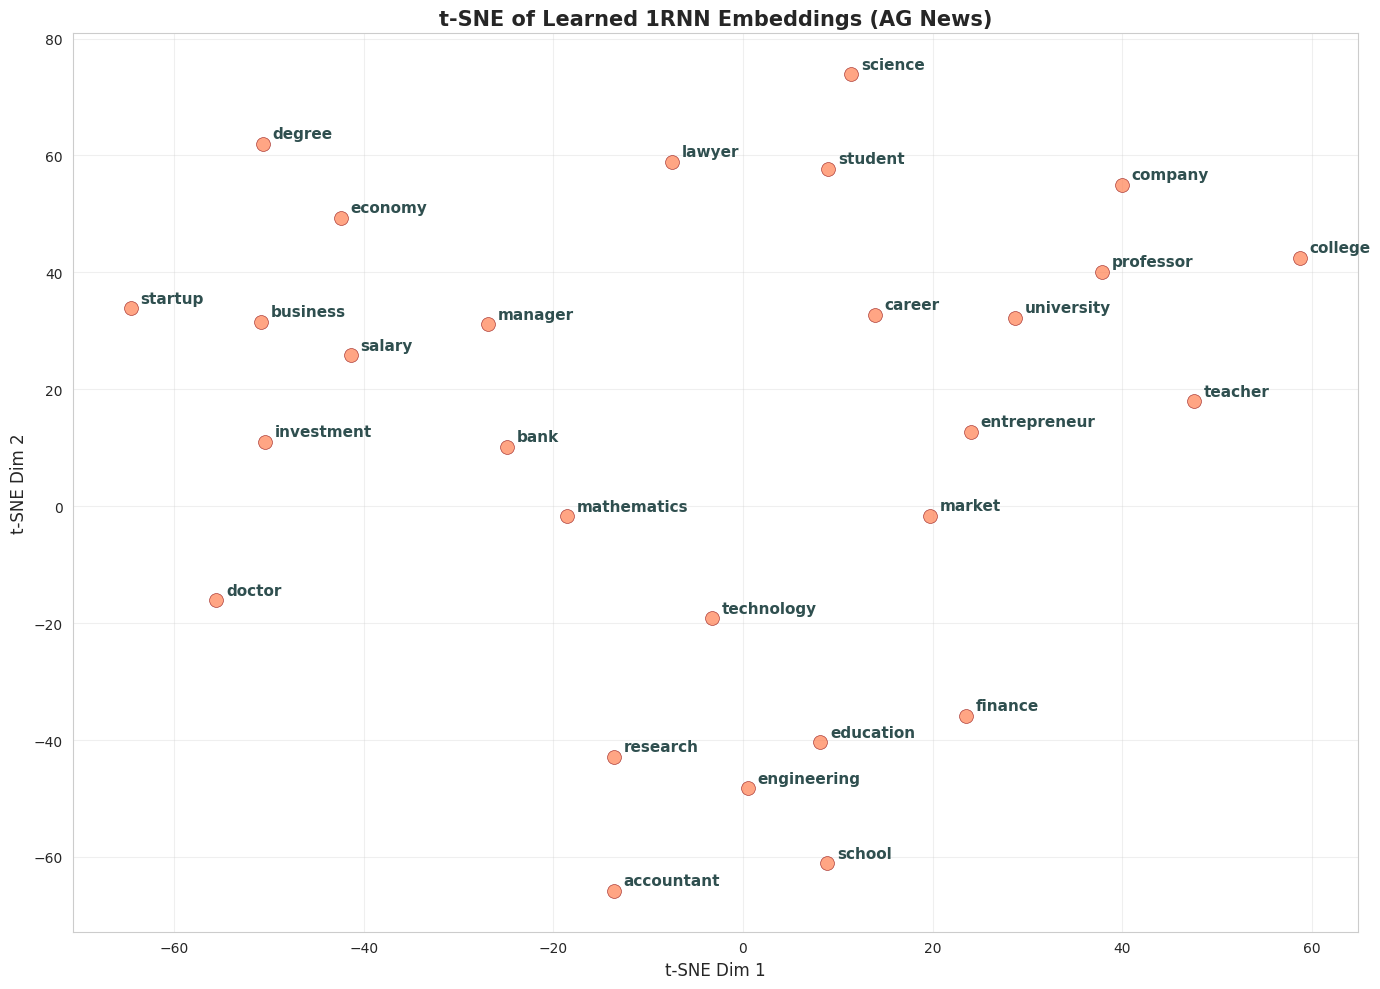

Plot saved as 'tsne_rnn_part_c.png'


In [10]:
tsne_words = [
    'business', 'career', 'student', 'university', 'college',
    'education', 'teacher', 'professor', 'school', 'degree',
    'economy', 'market', 'finance', 'investment', 'bank',
    'company', 'startup', 'entrepreneur', 'manager', 'salary',
    'science', 'research', 'technology', 'engineering', 'mathematics',
    'doctor', 'lawyer', 'accountant'
]

# Extract embeddings from the trained 1RNN model
rnn1_model = base_rnn1_model
if rnn1_model is None:
    print('ERROR: 1RNN model not found in trained_models dict.')
else:
    embedding_weights = rnn1_model.embedding_layer.weight.data.cpu().numpy()
    word_vectors = []
    valid_words = []
    for word in tsne_words:
        idx = base_vocab[word]  # returns <UNK> index if not found
        if idx != base_vocab['<UNK>']:
            word_vectors.append(embedding_weights[idx])
            valid_words.append(word)
        else:
            print(f"'{word}' not in vocabulary, skipping.")

    word_vectors = np.array(word_vectors)
    print(f'Collected {len(valid_words)} word vectors')

    # t-SNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=4, n_iter=2000)
    embeddings_2d = tsne.fit_transform(word_vectors)

    plt.figure(figsize=(14, 10))
    plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
                c='coral', s=100, alpha=0.7, edgecolors='darkred', linewidths=0.5)
    for i, word in enumerate(valid_words):
        plt.annotate(word, xy=(embeddings_2d[i, 0], embeddings_2d[i, 1]),
                     xytext=(7, 4), textcoords='offset points',
                     fontsize=11, fontweight='bold', color='darkslategray')

    plt.title('t-SNE of Learned 1RNN Embeddings (AG News)', fontsize=15, fontweight='bold')
    plt.xlabel('t-SNE Dim 1', fontsize=12)
    plt.ylabel('t-SNE Dim 2', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('tsne_rnn_part_c.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Plot saved as 'tsne_rnn_part_c.png'")

### **Your Observations:**

> **Q: Compare the learned 1RNN t-SNE plot to the pre-trained GloVe plot from Part A. What differences do you notice? Why might they differ?**

*[Your answer here]*

## 12. Running Variations

To run each variation, go back to **Section 2 (Hyperparameters)** and change the toggle variables:

| Variation | Settings |
|-----------|----------|
| MAX_WORDS=50 | `MAX_WORDS = 50` |
| GloVe init (trainable) | `USE_GLOVE = True`, `FREEZE_EMBEDDINGS = False` |
| GloVe init (frozen) | `USE_GLOVE = True`, `FREEZE_EMBEDDINGS = True` |
| IMDB dataset | `USE_IMDB = True` |

Then **re-run all cells** from Section 3 onwards.

### **Your Observations on Variations:**

> **Q: How does increasing MAX_WORDS to 50 affect accuracy and training time?**

*[Your answer here]*

> **Q: Does pre-trained GloVe initialization help? What about freezing vs. fine-tuning?**

*[Your answer here]*

> **Q: How do results compare on IMDB (binary sentiment) vs AG News (4-class topic)?**

*[Your answer here]*